In [1]:
from google.colab import auth; auth.authenticate_user()
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 58.7 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mne
import seaborn as sns

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import RobustScaler


In [8]:
##Importa dataset da Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yosftag/open-nuro-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.17G/4.17G [00:44<00:00, 100MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import mne

root = Path("/root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1/dataset/derivatives")
out = root / "psd_bands.parquet"

all_rows = []

# Trova tutte le cartelle sub-XX
subs = sorted(root.glob("sub-*"))

for sub in subs:
    print("PROCESSO:", sub.name)

    # Dentro ogni sub-XX c'è una cartella eeg/
    eeg_dir = sub / "eeg"
    if not eeg_dir.exists():
        print("  Nessuna cartella eeg/, salto.")
        continue

    # Cerca file .set dentro la cartella eeg/
    files = list(eeg_dir.glob("*.set"))
    if len(files) == 0:
        print("  Nessun file .set trovato, salto.")
        continue

    fset = files[0]
    print("  File:", fset.name)

    # Carica il file
    data = mne.io.read_raw_eeglab(fset, preload=True)

    # ICA veloce
    ica = mne.preprocessing.ICA(n_components=19, random_state=42)
    ica.fit(data)
    data_clean = data.copy()
    ica.apply(data_clean)

    # ===============================
    #   EPOCATURE 30s, overlap 50%
    # ===============================
    epoch_length = 30.0
    step = 15.0  # 50% overlap

    max_t = data_clean.times[-1]
    events = []
    event_id = {"epoch": 1}

    start = 0.0
    while start + epoch_length <= max_t:
        onset_sample = int(start * data_clean.info["sfreq"])
        events.append([onset_sample, 0, 1])
        start += step

    events = np.array(events)

    epochs = mne.Epochs(
        data_clean,
        events,
        event_id=event_id,
        tmin=0,
        tmax=epoch_length,
        baseline=None,
        preload=True
    )

    # ===============================
    #   PSD su epoche
    # ===============================
    psd = epochs.compute_psd(
        method="welch",
        fmin=0.45, fmax=45,
        n_fft=512,
        picks="eeg"
    )

    freqs = psd.freqs
    psd_data = psd.get_data()  # (n_epochs, n_channels, n_freqs)
    ch_names = psd.ch_names

    # ===============================
    #   BANDE DI FREQUENZA
    # ===============================
    bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 12),
        "beta": (12, 30),
        "gamma": (30, 45),
    }

    # Trasformo tutto in righe (solo bande)
    for ep in range(psd_data.shape[0]):
        for ch_i, ch in enumerate(ch_names):
            psd_ch = psd_data[ep, ch_i, :]

            for band_name, (fmin, fmax) in bands.items():
                idx = (freqs >= fmin) & (freqs < fmax)
                band_mean = float(psd_ch[idx].mean())

                all_rows.append({
                    "participant_id": sub.name,
                    "epoch": ep,
                    "channel": ch,
                    "band": band_name,
                    "psd_band_mean": band_mean
                })

# Salvo tutto in un unico file (solo bande)
df = pd.DataFrame(all_rows)
df.to_parquet(out, index=False)

print("\nFINITO!")
print("File creato:", out)

OSError: Cannot save file into a non-existent directory: '/root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1/dataset/derivatives'

In [ ]:

from pathlib import Path

root = Path("/root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1/dataset/derivatives")
out = root / "psd_all.parquet"

all_rows = []



# Trova tutte le cartelle sub-XX
subs = sorted(root.glob("sub-*"))

for sub in subs:
    print("PROCESSO:", sub.name)

    #  Dentro ogni sub-XX c'è una cartella eeg/
    eeg_dir = sub / "eeg"
    if not eeg_dir.exists():
        print("  Nessuna cartella eeg/, salto.")
        continue

    #  Cerca file .set dentro la cartella eeg/
    files = list(eeg_dir.glob("*.set"))
    if len(files) == 0:
        print("  Nessun file .set trovato, salto.")
        continue

    fset = files[0]
    print("  File:", fset.name)

    #  Carica il file
    data = mne.io.read_raw_eeglab(fset, preload=True)


    #  ICA veloce
    ica = mne.preprocessing.ICA(n_components=19, random_state=42)
    ica.fit(data)
    data_clean = data.copy()
    ica.apply(data_clean)

    #  Calcolo PSD
    psd = data_clean.compute_psd(
        method="welch",
        fmin=0.45, fmax=45,
        n_fft=512,
        picks="eeg"
    )

    freqs = psd.freqs
    psd_data = psd.get_data()     # (n_channels, n_freqs)
    ch_names = psd.ch_names

    #  Trasformo tutto in righe
    for ch_i, ch in enumerate(ch_names):
        for fi, f in enumerate(freqs):
            all_rows.append({
                "participant_id": sub.name,    # es: sub-01
                "channel": ch,
                "frequency": float(f),
                "psd": float(psd_data[ch_i, fi])
            })

#  Salvo tutto in un unico file
df = pd.DataFrame(all_rows)
df.to_parquet(out, index=False)

print("\nFINITO!")
print("File creato:", out)


PROCESSO: sub-001
  File: sub-001_task-eyesclosed_eeg.set
Fitting ICA to data using 19 channels (please be patient, this may take a while)


/tmp/ipykernel_1496/3224462879.py:38: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(data)


Selecting by number: 19 components
Fitting ICA took 18.9s.
Applying ICA to Raw instance
    Transforming to ICA space (19 components)
    Zeroing out 0 ICA components
    Projecting back using 19 PCA components


/tmp/ipykernel_1496/3224462879.py:38: RuntimeWarning: Using n_components=19 (resulting in n_components_=19) may lead to an unstable mixing matrix estimation because the ratio between the largest (18) and smallest (9.4e-15) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 16
  ica.fit(data)


Effective window size : 1.024 (s)
PROCESSO: sub-002
  File: sub-002_task-eyesclosed_eeg.set
Fitting ICA to data using 19 channels (please be patient, this may take a while)


...

Fitting ICA took 11.1s.
Applying ICA to Raw instance
    Transforming to ICA space (19 components)
    Zeroing out 0 ICA components
    Projecting back using 19 PCA components
Effective window size : 1.024 (s)
PROCESSO: sub-088
  File: sub-088_task-eyesclosed_eeg.set
Fitting ICA to data using 19 channels (please be patient, this may take a while)


/tmp/ipykernel_1496/3224462879.py:33: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  data = mne.io.read_raw_eeglab(fset, preload=True)
/tmp/ipykernel_1496/3224462879.py:38: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(data)


Selecting by number: 19 components
Fitting ICA took 13.0s.


/tmp/ipykernel_1496/3224462879.py:38: RuntimeWarning: Using n_components=19 (resulting in n_components_=19) may lead to an unstable mixing matrix estimation because the ratio between the largest (18) and smallest (9.2e-15) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 16
  ica.fit(data)


Applying ICA to Raw instance
    Transforming to ICA space (19 components)
    Zeroing out 0 ICA components
    Projecting back using 19 PCA components
Effective window size : 1.024 (s)

FINITO!
File creato: /root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1/dataset/derivatives/psd_all.parquet


In [9]:
import os
tsv_path = "/root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1/dataset/participants.tsv"
print(tsv_path)
participants = pd.read_csv(tsv_path, sep='\t')
print(participants)
mappa = pd.read_csv(tsv_path, sep='\t', dtype={"participant_id": str, "Group": str})



/root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1/dataset/participants.tsv
   participant_id Gender  Age Group  MMSE
0         sub-001      F   57     A    16
1         sub-002      F   78     A    22
2         sub-003      M   70     A    14
3         sub-004      F   67     A    20
4         sub-005      M   70     A    22
..            ...    ...  ...   ...   ...
83        sub-084      F   71     F    24
84        sub-085      M   64     F    26
85        sub-086      M   49     F    26
86        sub-087      M   73     F    24
87        sub-088      M   55     F    24

[88 rows x 5 columns]


Using matplotlib as 2D backend.


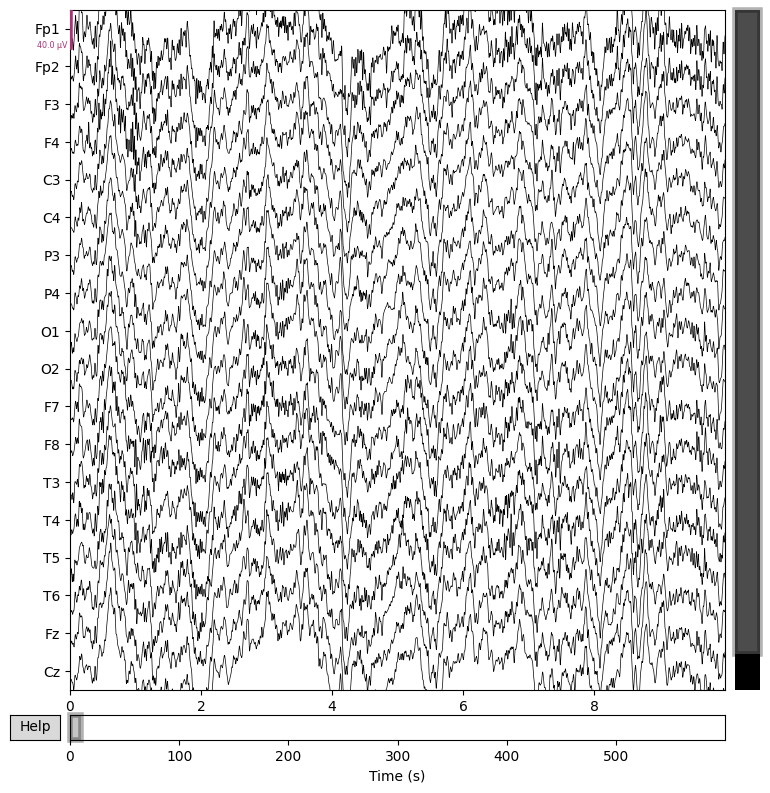

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
>


In [88]:

file_path = '/root/.cache/kagglehub/datasets/yosftag/open-nuro-dataset/versions/1/dataset/derivatives/sub-001/eeg/sub-001_task-eyesclosed_eeg.set'
raw = mne.io.read_raw_eeglab(file_path, preload=True)
raw.plot(n_channels=18)
print(raw.info)

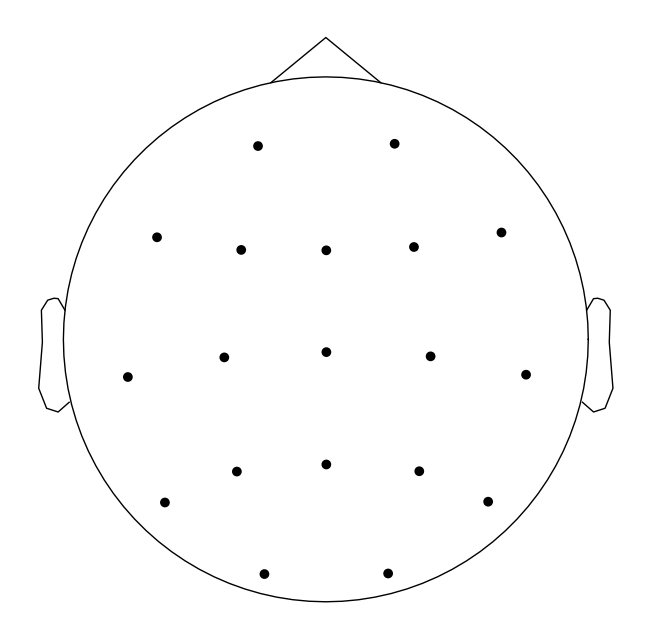

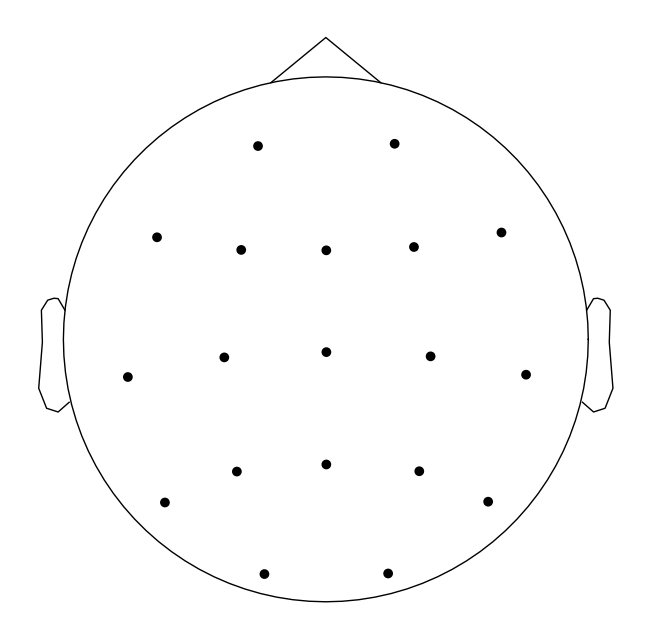

In [89]:
raw.plot_sensors(kind='topomap', ch_type='eeg', sphere=(0,0,0,0.12))

In [ ]:
from mne.preprocessing import ICA

In [ ]:
#Applico ICA per rimuovere artefatti come battito occhi, ECG ecc...
ica = mne.preprocessing.ICA(n_components=18, random_state=42, max_iter='auto')
ica.fit(raw)
data_clean = ica.apply(raw.copy())

Fitting ICA to data using 19 channels (please be patient, this may take a while)


/tmp/ipykernel_1496/2443663254.py:3: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Selecting by number: 18 components
Fitting ICA took 18.1s.
Applying ICA to Raw instance
    Transforming to ICA space (18 components)
    Zeroing out 0 ICA components
    Projecting back using 19 PCA components


/tmp/ipykernel_1496/2443663254.py:3: RuntimeWarning: Using n_components=18 (resulting in n_components_=18) may lead to an unstable mixing matrix estimation because the ratio between the largest (18) and smallest (9.8e-15) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 16
  ica.fit(raw)


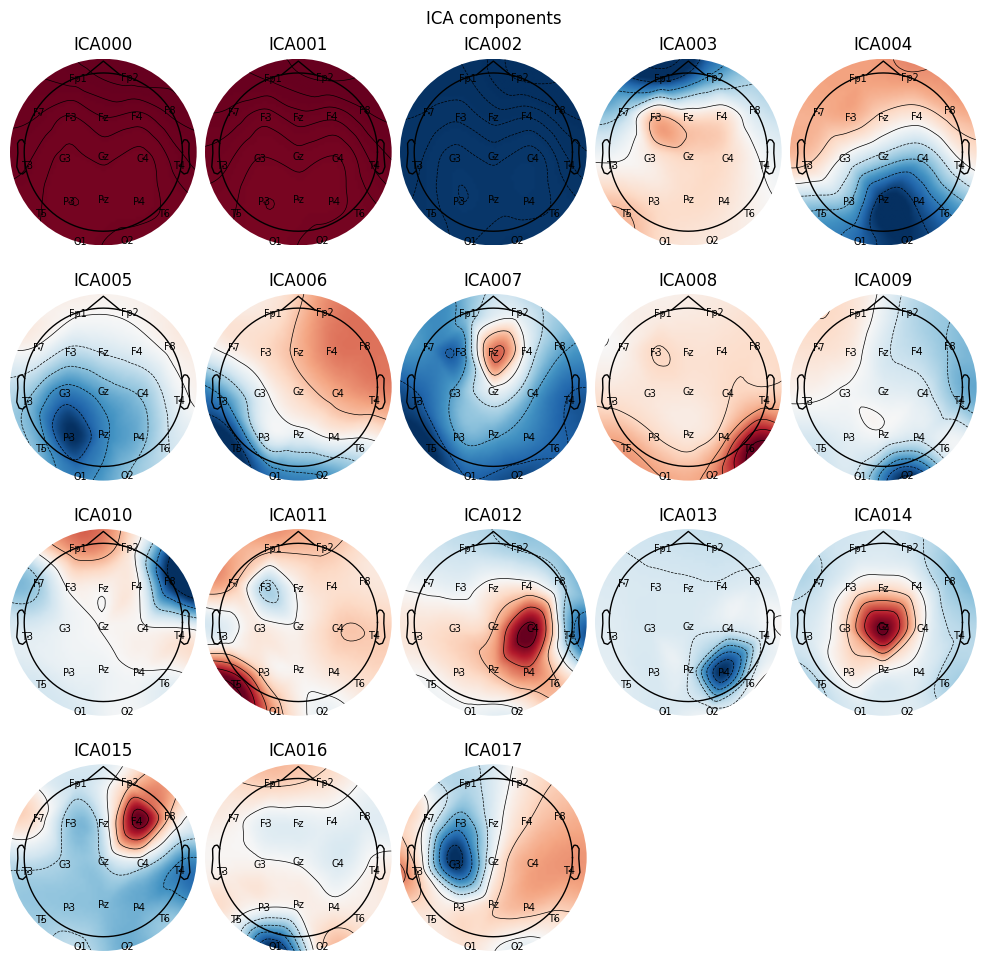

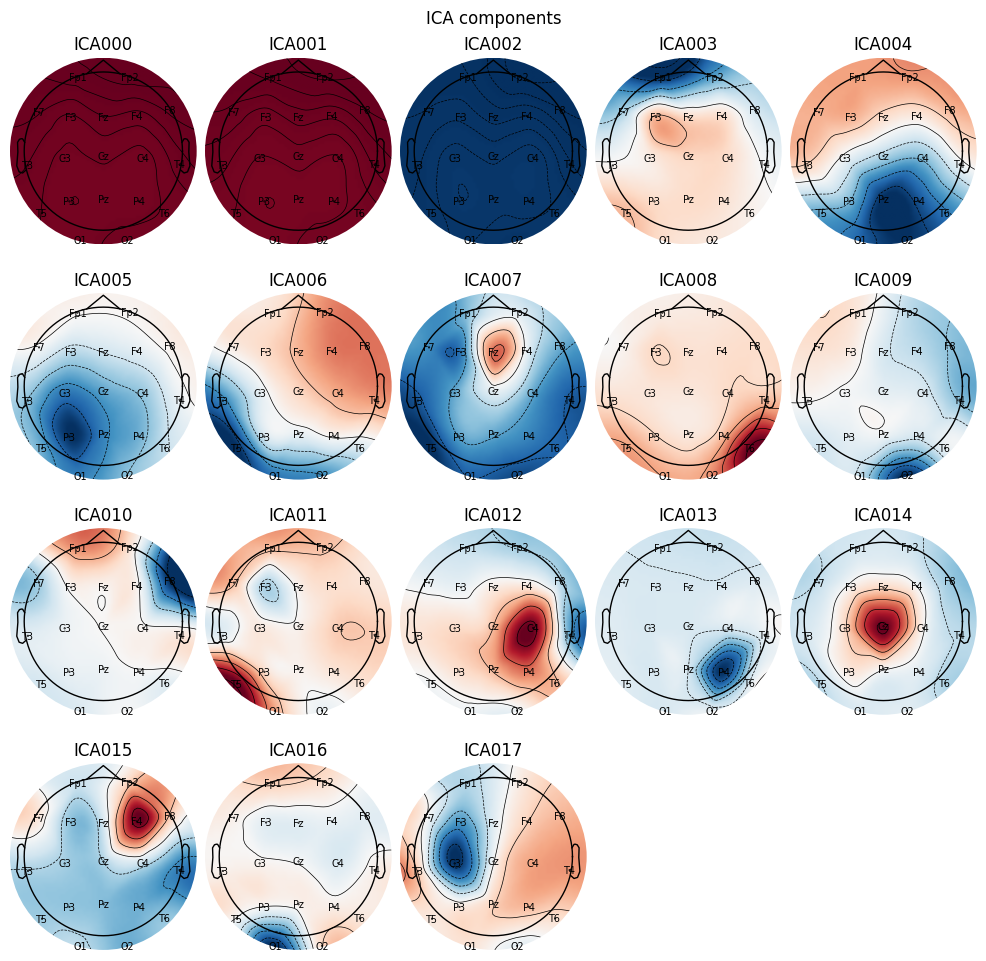

In [ ]:
ica.plot_components(show_names=True)

Cerco delle feature che possono essere maggiormente correlate rispetto ad altre. Dal plot il range tra 8-10 Hz e  35-40 Hz ha un coefficiente di Pearson più elevato in modulo assoluto

Verifying 'Group' column after re-preparation:


,count
Group,
1,179360
0,148485
2,101650


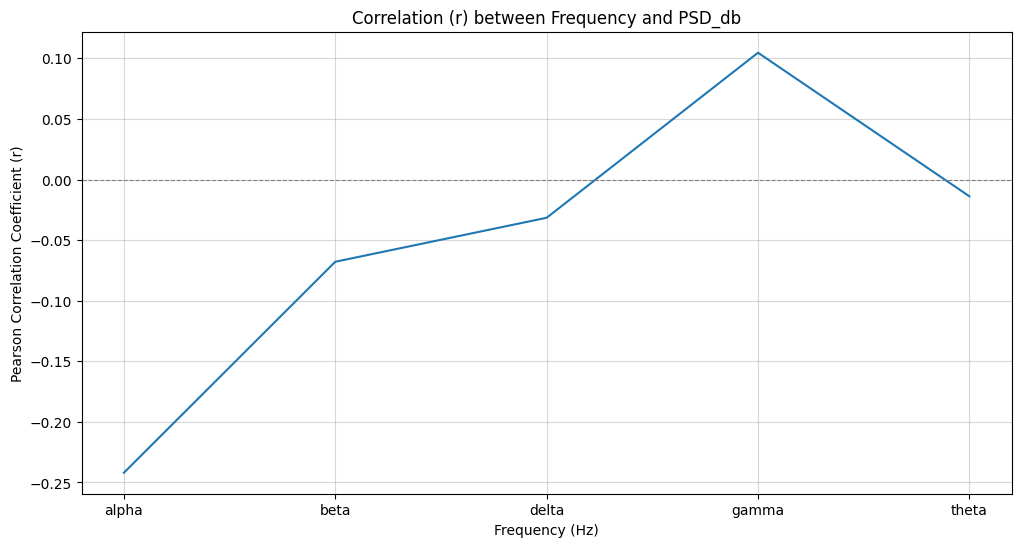

In [11]:
from scipy.stats import pearsonr

#carico dataframe da file .parquet
df = pd.read_parquet("/content/drive/MyDrive/psd_bands.parquet")

# Merge con mappa per ottenere la colonna Group
df = df.merge(mappa, on='participant_id', how='left')

# Converto la stringa gruppo in float
df['Group'] = df['Group'].map({'A': 1, 'F': 2, 'C': 0})

# Calcolo le psdb in dB
df['psd_db'] = 10 * np.log10(df['psd_band_mean'])

print("Verifying 'Group' column after re-preparation:")
display(df['Group'].value_counts(dropna=False))

# Now proceed with correlation calculation
results = []

for f, d in df.groupby('band'):
    # Only calculate correlation if there are at least two unique groups present
    if d['Group'].nunique() > 1:
        r, p = pearsonr(d['psd_db'], d['Group'])
        results.append((f, r, p))

corr_df = pd.DataFrame(results, columns=['band', 'r', 'p'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x='band', y='r')
plt.title('Correlation (r) between Frequency and PSD_db')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Pearson Correlation Coefficient (r)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True, which='both', ls='-', alpha=0.5)
plt.show()


In [40]:
##Considero solo le frequenze con correlazione più alta
bands_of_interest = ['alpha', 'gamma','beta','delta']
df_feat = df[df['band'].isin(bands_of_interest)].copy()


In [41]:
#Creo un nuovo dataframe con le feauture che mi interessano
df_feat_subj = (
    df_feat.groupby(['participant_id', 'channel', 'band', 'Gender', 'Age', 'Group'])['psd_band_mean']
    .mean()
    .reset_index()
)
df_feat_subj['psd_band_mean_dB'] = 10 * np.log10(df_feat_subj['psd_band_mean'])
wide = df_feat_subj.pivot_table(
    index=['participant_id', 'Gender', 'Age', 'Group'],
    columns=['channel', 'band'],
    values='psd_band_mean_dB'
)
wide.columns = [f"{ch}_{band}" for ch, band in wide.columns]
wide = wide.reset_index()
wide.head()

,participant_id,Gender,Age,Group,C3_alpha,C3_beta,C3_delta,C3_gamma,C4_alpha,C4_beta,...,T4_delta,T4_gamma,T5_alpha,T5_beta,T5_delta,T5_gamma,T6_alpha,T6_beta,T6_delta,T6_gamma
0,sub-001,F,57,1,-116.810304,-122.635089,-98.819466,-128.373043,-116.824522,-122.595310,...,-98.775246,-125.171069,-115.525928,-120.738210,-98.667556,-123.589724,-116.056594,-121.888527,-98.699724,-126.804803
1,sub-002,F,78,1,-115.670824,-122.451681,-99.256463,-128.275230,-115.867036,-122.481699,...,-99.195766,-123.189898,-110.073027,-120.531519,-99.145405,-126.979896,-110.162612,-120.820023,-99.162871,-126.880784
2,sub-003,M,70,1,-113.735699,-122.634447,-100.114606,-129.458677,-113.646482,-122.635080,...,-99.973110,-128.100485,-108.738871,-121.528401,-99.755890,-127.993132,-106.447941,-121.230056,-99.785247,-128.526152
3,sub-004,F,67,1,-116.614101,-122.272994,-98.829242,-125.984987,-116.623647,-122.382767,...,-98.691156,-120.848738,-116.385142,-121.925579,-98.644650,-125.285168,-116.373999,-121.731825,-98.641646,-124.460461
4,sub-005,M,70,1,-116.468614,-122.409957,-98.970750,-127.404669,-116.365848,-122.326533,...,-98.884935,-124.140572,-114.510357,-120.611225,-98.783329,-125.236084,-114.784199,-120.386650,-98.863322,-125.323514


In [14]:
df_feat_subj.head()

,participant_id,channel,band,Gender,Age,Group,psd_band_mean,psd_band_mean_dB
0,sub-001,C3,alpha,F,57,1,2.084345e-12,-116.810304
1,sub-001,C3,gamma,F,57,1,1.454439e-13,-128.373043
2,sub-001,C4,alpha,F,57,1,2.077533e-12,-116.824522
3,sub-001,C4,gamma,F,57,1,1.552866e-13,-128.088659
4,sub-001,Cz,alpha,F,57,1,2.098184e-12,-116.781564


In [ ]:
wide.head()


,participant_id,Gender,Age,Group,C3_alpha,C3_gamma,C4_alpha,C4_gamma,Cz_alpha,Cz_gamma,...,Pz_alpha,Pz_gamma,T3_alpha,T3_gamma,T4_alpha,T4_gamma,T5_alpha,T5_gamma,T6_alpha,T6_gamma
0,sub-001,F,57,1,-116.810304,-128.373043,-116.824522,-128.088659,-116.781564,-127.878250,...,-116.528744,-128.638683,-116.355582,-126.205083,-116.361174,-125.171069,-115.525928,-123.589724,-116.056594,-126.804803
1,sub-002,F,78,1,-115.670824,-128.275230,-115.867036,-128.247251,-114.657567,-128.268172,...,-112.076592,-128.009024,-112.204636,-123.514929,-113.757063,-123.189898,-110.073027,-126.979896,-110.162612,-126.880784
2,sub-003,M,70,1,-113.735699,-129.458677,-113.646482,-129.392555,-114.315506,-128.793022,...,-111.222018,-129.087950,-111.627916,-128.603896,-112.099666,-128.100485,-108.738871,-127.993132,-106.447941,-128.526152
3,sub-004,F,67,1,-116.614101,-125.984987,-116.623647,-126.357115,-116.551505,-127.104594,...,-116.575638,-126.623346,-115.888789,-122.252651,-115.874562,-120.848738,-116.385142,-125.285168,-116.373999,-124.460461
4,sub-005,M,70,1,-116.468614,-127.404669,-116.365848,-127.518209,-116.561822,-128.111513,...,-116.002503,-127.324827,-115.157791,-120.470219,-115.392390,-124.140572,-114.510357,-125.236084,-114.784199,-125.323514


In [42]:
#Creo dataframe con le feauture per il mio modello ML e uno con i target
X_full_features = wide.drop(columns=['participant_id', 'Group','Gender','Age'])
y_full = wide['Group']
# Stampa le dimensioni dei nuovi set di dati
print("Shape di X_full_features (features complete):".ljust(40), X_full_features.shape)
print("Shape di y_full (target completo):".ljust(40), y_full.shape)

# Visualizza le prime righe delle feature e del target
print("\nPrime 5 righe di X_full_features:")
display(X_full_features.head())
print("\nPrime 5 righe di y_full:")
display(y_full.head())

Shape di X_full_features (features complete): (88, 76)
Shape di y_full (target completo):       (88,)

Prime 5 righe di X_full_features:


,C3_alpha,C3_beta,C3_delta,C3_gamma,C4_alpha,C4_beta,C4_delta,C4_gamma,Cz_alpha,Cz_beta,...,T4_delta,T4_gamma,T5_alpha,T5_beta,T5_delta,T5_gamma,T6_alpha,T6_beta,T6_delta,T6_gamma
0,-116.810304,-122.635089,-98.819466,-128.373043,-116.824522,-122.595310,-98.817794,-128.088659,-116.781564,-122.539178,...,-98.775246,-125.171069,-115.525928,-120.738210,-98.667556,-123.589724,-116.056594,-121.888527,-98.699724,-126.804803
1,-115.670824,-122.451681,-99.256463,-128.275230,-115.867036,-122.481699,-99.304009,-128.247251,-114.657567,-121.880236,...,-99.195766,-123.189898,-110.073027,-120.531519,-99.145405,-126.979896,-110.162612,-120.820023,-99.162871,-126.880784
2,-113.735699,-122.634447,-100.114606,-129.458677,-113.646482,-122.635080,-100.006415,-129.392555,-114.315506,-122.456413,...,-99.973110,-128.100485,-108.738871,-121.528401,-99.755890,-127.993132,-106.447941,-121.230056,-99.785247,-128.526152
3,-116.614101,-122.272994,-98.829242,-125.984987,-116.623647,-122.382767,-98.809493,-126.357115,-116.551505,-122.177021,...,-98.691156,-120.848738,-116.385142,-121.925579,-98.644650,-125.285168,-116.373999,-121.731825,-98.641646,-124.460461
4,-116.468614,-122.409957,-98.970750,-127.404669,-116.365848,-122.326533,-98.974231,-127.518209,-116.561822,-122.407873,...,-98.884935,-124.140572,-114.510357,-120.611225,-98.783329,-125.236084,-114.784199,-120.386650,-98.863322,-125.323514



Prime 5 righe di y_full:


,Group
0,1
1,1
2,1
3,1
4,1


In [43]:
#Divido il dataset in 70% per training e 30% per test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_full_features, y_full,
    test_size=0.3,
    random_state=42,
    stratify=y_full
)
print("Train shape X:", X_train.shape, " y:", y_train.shape)
print("Test shape  X:", X_test.shape,  " y:", y_test.shape)

print("Distribuzione training:")
print(y_train.value_counts(normalize=True))

print("Distribuzione test:")
print(y_test.value_counts(normalize=True))

Train shape X: (61, 76)  y: (61,)
Test shape  X: (27, 76)  y: (27,)
Distribuzione training:
Group
1    0.409836
0    0.327869
2    0.262295
Name: proportion, dtype: float64
Distribuzione test:
Group
1    0.407407
0    0.333333
2    0.259259
Name: proportion, dtype: float64


In [17]:
def squared_inverse_distance(distances):
    return 1.0 / (distances**2 + 1e-12)

In [26]:
def gausssian (distances, sigma = 1.0):
    return np.exp(-distances**2)/(2*sigma**2)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.52676126 0.52676126 0.5365883  0.58440176 0.59177349 0.57745551
 0.61886344 0.59411195 0.64602633 0.5043739  0.5043739         nan
 0.54308732 0.53993256        nan 0.53497144 0.53067931        nan]
  warnings.warn(


Migliori parametri k-NN con features significative: {'knn__algorithm': 'brute', 'knn__metric': 'cosine', 'knn__n_neighbors': 7, 'knn__weights': <function gausssian at 0x7cbc2a3f8fe0>}
ROC AUC (test) con features significative: 0.7721661054994389


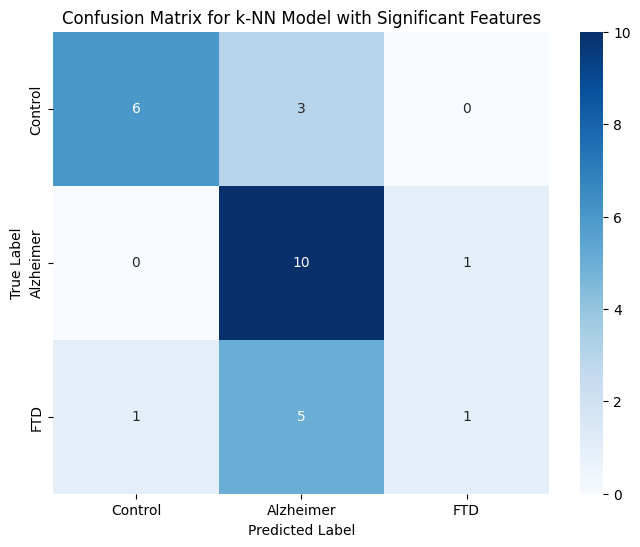

Classification Report con features significative:
               precision    recall  f1-score   support

     Control       0.86      0.67      0.75         9
   Alzheimer       0.56      0.91      0.69        11
         FTD       0.50      0.14      0.22         7

    accuracy                           0.63        27
   macro avg       0.64      0.57      0.55        27
weighted avg       0.64      0.63      0.59        27



In [53]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, Normalizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define the pipeline for KNN with scaling
pipe_knn_significant = Pipeline(
    [('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]
)

# Define the parameter grid for KNN
param_knn_significant = {
    'knn__n_neighbors': [2,4,7],
    'knn__weights': ['distance', squared_inverse_distance,gausssian ],
    'knn__metric': ['cosine','euclidean'],
    'knn__algorithm': ['brute']
}

# Initialize StratifiedGroupKFold for cross-validation
sgkf_significant = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

# Perform GridSearchCV
grid_knn_significant = GridSearchCV(
    estimator=pipe_knn_significant,
    param_grid=param_knn_significant,
    scoring="roc_auc_ovr",
    cv=sgkf_significant,


    n_jobs=-1,
    refit=True,
    verbose=0,
)

# Fit the GridSearchCV object to the training data
grid_knn_significant.fit(X_train, y_train, groups=wide.loc[X_train.index, 'participant_id']  )

print(
    "Migliori parametri k-NN con features significative:",
    grid_knn_significant.best_params_,
)

# Predict on the test set using the best estimator
y_pred_knn_significant = grid_knn_significant.predict(X_test)
y_proba_knn_significant = grid_knn_significant.predict_proba(X_test)

# Evaluate ROC AUC score
roc_auc_significant = roc_auc_score(
    y_test, y_proba_knn_significant, multi_class='ovr', average='macro'
)
print("ROC AUC (test) con features significative:", roc_auc_significant)

# Generate and plot the confusion matrix
cm_significant = confusion_matrix(y_test, y_pred_knn_significant)

class_names = ['Control', 'Alzheimer', 'FTD']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_significant,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('Confusion Matrix for k-NN Model with Significant Features')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print classification report for more detailed metrics
print(
    "Classification Report con features significative:\n",
    classification_report(
        y_test, y_pred_knn_significant, target_names=class_names
    ),
)


Migliori parametri k-NN con features significative: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
ROC AUC (test) con features significative: 0.7126803751803751


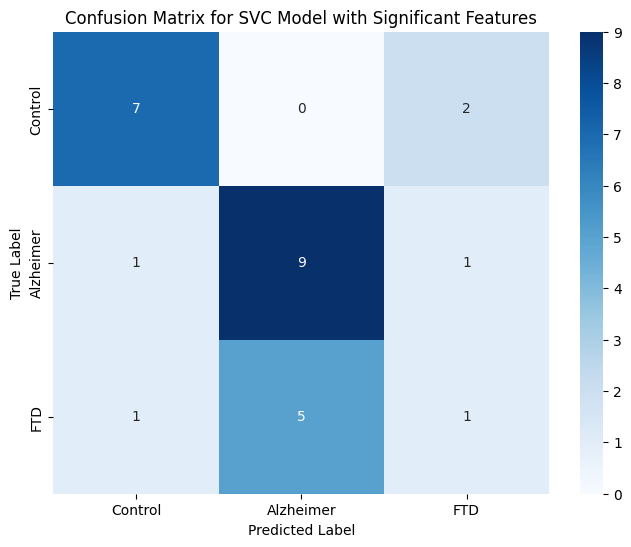

Classification Report con features significative:
               precision    recall  f1-score   support

     Control       0.78      0.78      0.78         9
   Alzheimer       0.64      0.82      0.72        11
         FTD       0.25      0.14      0.18         7

    accuracy                           0.63        27
   macro avg       0.56      0.58      0.56        27
weighted avg       0.59      0.63      0.60        27



In [83]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC




pipe_svc_significant = Pipeline(
    [('scaler', StandardScaler()), ('svc', SVC(probability=True))]
)

# Define the parameter grid for SVC

param_svc_significant = {
    'svc__kernel': ['poly','rbf'],
    'svc__C': [0.1,1,10,15, 100],
    'svc__gamma': ['scale', 'auto'],
    'svc__class_weight': [ 'balanced',None],
    'svc__degree': [2] # #Uso una funzione quadratica, grado 2
}



# Initialize StratifiedGroupKFold for cross-validation
sgkf_significant = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

# Perform GridSearchCV
grid_svc_significant = GridSearchCV(
    estimator=pipe_svc_significant,
    param_grid=param_svc_significant,
    scoring="roc_auc_ovr",
    cv=sgkf_significant.split(
        X_train, y_train, groups=wide.loc[X_train.index, 'participant_id']
    ),
    n_jobs=-1,
    refit=True,
    verbose=0,
)

# Fit the GridSearchCV object to the training data
grid_svc_significant.fit(X_train, y_train, groups=wide.loc[X_train.index, 'participant_id'] )

print(
    "Migliori parametri k-NN con features significative:",
    grid_svc_significant.best_params_,
)

# Predict on the test set using the best estimator
y_pred_svc_significant = grid_svc_significant.predict(X_test)
y_proba_svc_significant = grid_svc_significant.predict_proba(X_test)

# Evaluate ROC AUC score
roc_auc_significant = roc_auc_score(
    y_test, y_proba_svc_significant, multi_class='ovr', average='macro'
)
print("ROC AUC (test) con features significative:", roc_auc_significant)

# Generate and plot the confusion matrix
cm_significant_svc = confusion_matrix(y_test, y_pred_svc_significant)

class_names = ['Control', 'Alzheimer', 'FTD']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_significant_svc,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('Confusion Matrix for SVC Model with Significant Features')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print classification report for more detailed metrics
print(
    "Classification Report con features significative:\n",
    classification_report(
        y_test, y_pred_svc_significant, target_names=class_names
    ),
)


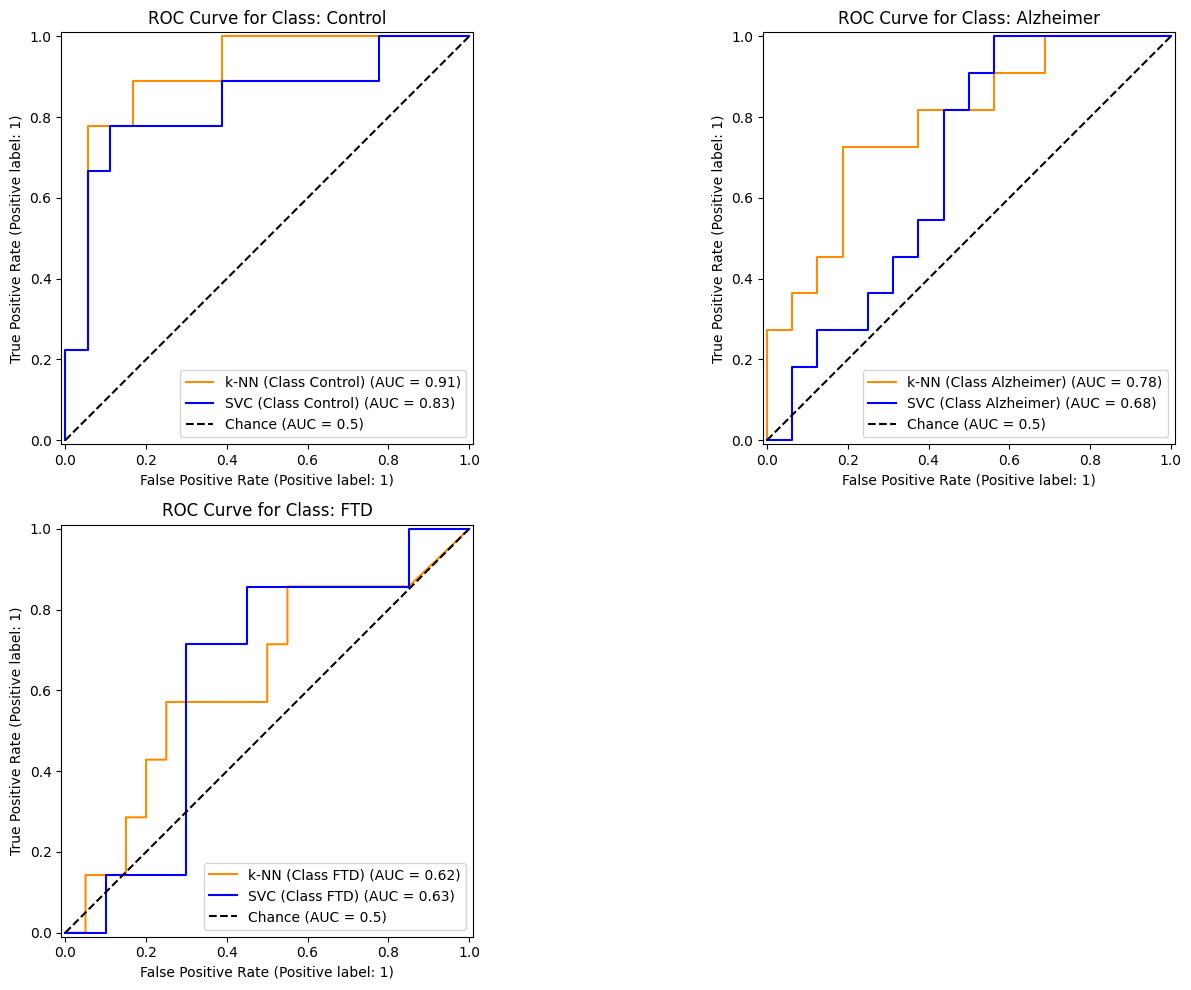

In [84]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize
import numpy as np

# Map original group names to numerical labels if not already done

class_names = ['Control', 'Alzheimer', 'FTD']
n_classes = len(class_names)

# Binarize the true labels for OvR plotting
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(15, 10))

# Plot ROC curve for each class
for i in range(n_classes):
    ax = plt.subplot(2, 2, i + 1) # Create subplots for each class

    # Plot k-NN ROC curve for current class
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i], # True binary labels for class i
        y_proba_knn_significant[:, i], # Predicted probabilities for class i from k-NN
        name=f'k-NN (Class {class_names[i]})',
        color='darkorange',
        ax=ax
    )

    # Plot SVC ROC curve for current class
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        y_proba_svc_significant[:, i],
        name=f'SVC (Class {class_names[i]})',
        color='blue',
        ax=ax
    )

    ax.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.5)') # Plot random chance line
    ax.set_title(f'ROC Curve for Class: {class_names[i]}')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()